# Analiza Danych

## Wczytanie scalonego i zwalidowanego zbioru danych 

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wykresów
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Dodanie katalogu głównego do ścieżek
root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from src.config import DATASET_2022_PATH

# Wczytanie gotowego zbioru
df = pd.read_parquet(DATASET_2022_PATH)

print(f"Załadowano obserwacji: {len(df):,}")
print(f"Liczba stacji: {df['station'].nunique()}")
df.head()

Załadowano obserwacji: 123,694
Liczba stacji: 15


,timestamp,station,data_source,lat,lon,altitude,urban_fraction_500m,sin_hour,cos_hour,sin_doy,cos_doy,temp_era5,temp_ground,guminski_season,delta_temp,hour
0,2022-01-01,Aleksandrowice,lcs,50.081104,19.764215,242.385681,0.2129,0.0,1.0,0.017202,0.999852,8.454773,8.5,zima,0.045227,0
1,2022-01-01,Biezanow Prokocim,lcs,50.019761,20.052830,208.093094,0.5512,0.0,1.0,0.017202,0.999852,8.989929,9.1,zima,0.110071,0
2,2022-01-01,Debniki,lcs,50.033099,19.895774,214.787842,0.3366,0.0,1.0,0.017202,0.999852,8.778992,8.9,zima,0.121008,0
3,2022-01-01,Grabie,lcs,50.039521,20.134673,197.447372,0.1164,0.0,1.0,0.017202,0.999852,8.989929,9.2,zima,0.210071,0
4,2022-01-01,Krakow-Balice,imgw,50.077700,19.784800,238.000000,0.2566,0.0,1.0,0.017202,0.999852,8.454773,9.2,zima,0.745227,0


## Eksploracyjna Analiza Danych (EDA)

C:\Users\nczop\AppData\Local\Temp\ipykernel_12244\2268596908.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='urban_bin', y='delta_temp', palette='Reds', ax=axes[0, 1])


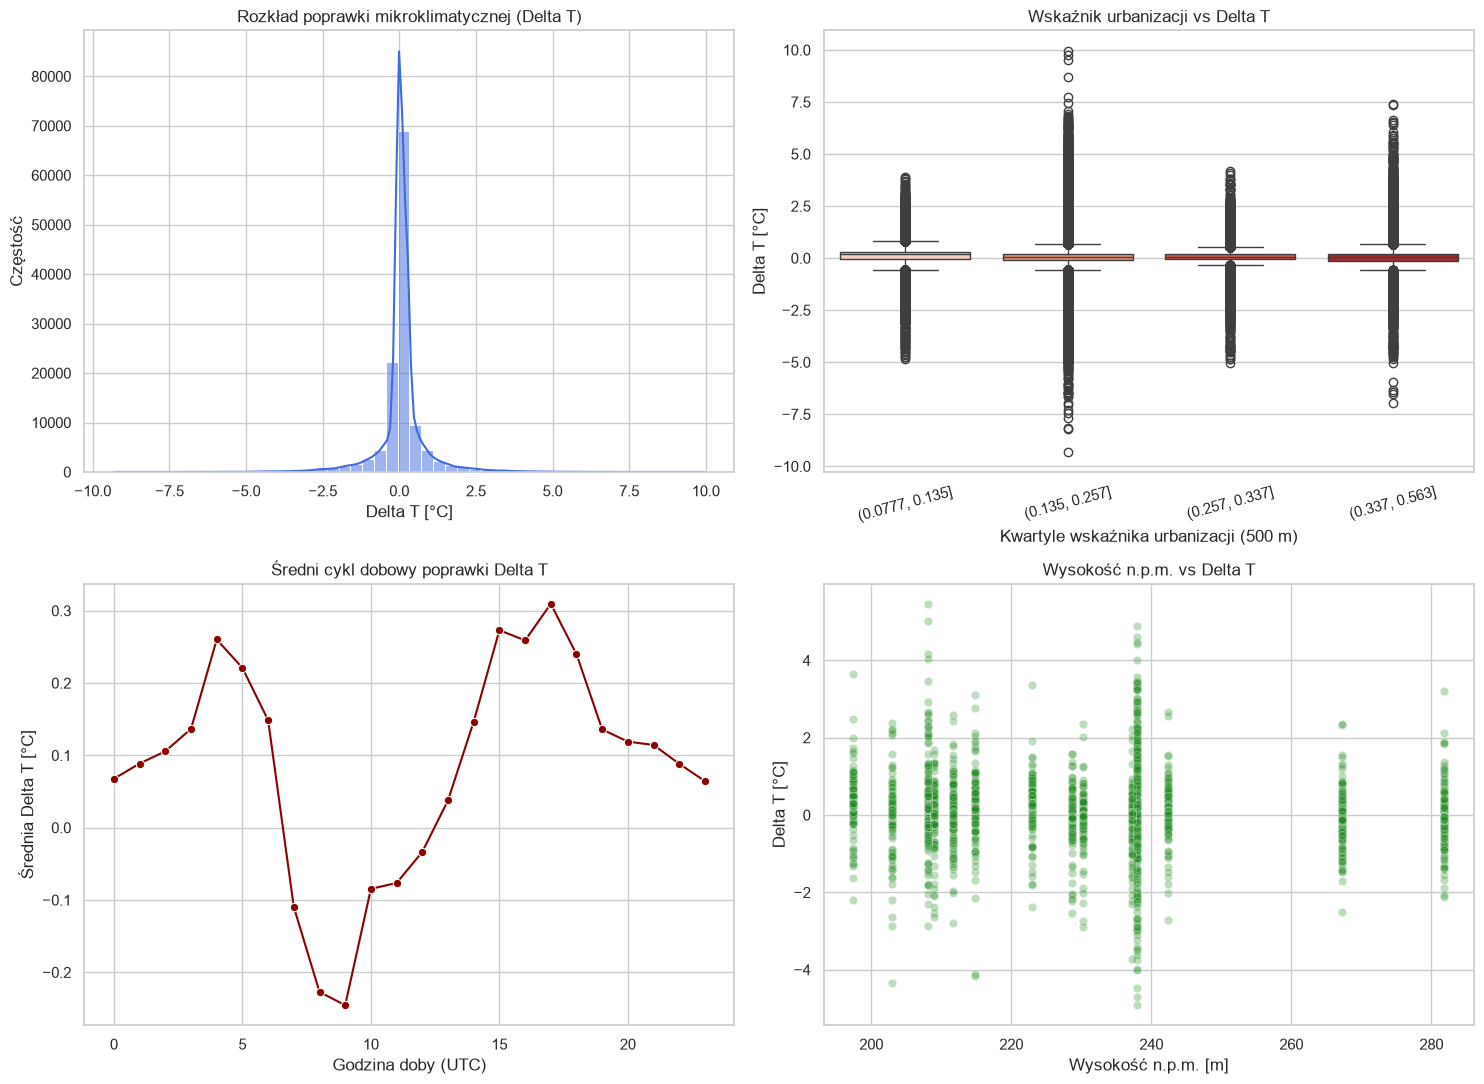

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Wykres 1: Rozkład poprawki mikroklimatycznej (Delta T)
sns.histplot(df['delta_temp'], bins=50, kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title("Rozkład poprawki mikroklimatycznej (Delta T)")
axes[0, 0].set_xlabel("Delta T [°C]")
axes[0, 0].set_ylabel("Częstość")

# Wykres 2: Wpływ urbanizacji na Delta T (UHI)
df['urban_bin'] = pd.qcut(df['urban_fraction_500m'], q=4, duplicates='drop')
sns.boxplot(data=df, x='urban_bin', y='delta_temp', palette='Reds', ax=axes[0, 1])
axes[0, 1].set_title("Wskaźnik urbanizacji vs Delta T")
axes[0, 1].set_xlabel("Kwartyle wskaźnika urbanizacji (500 m)")
axes[0, 1].set_ylabel("Delta T [°C]")
axes[0, 1].tick_params(axis='x', rotation=15)

# Wykres 3: Średni cykl dobowy poprawki
hourly_profile = df.groupby('hour')['delta_temp'].mean().reset_index()
sns.lineplot(data=hourly_profile, x='hour', y='delta_temp', marker='o', color='darkred', ax=axes[1, 0])
axes[1, 0].set_title("Średni cykl dobowy poprawki Delta T")
axes[1, 0].set_xlabel("Godzina doby (UTC)")
axes[1, 0].set_ylabel("Średnia Delta T [°C]")

# Wykres 4: Korelacja z wysokością n.p.m.
sample_df = df.sample(min(4000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x='altitude', y='delta_temp', alpha=0.3, color='forestgreen', ax=axes[1, 1])
axes[1, 1].set_title("Wysokość n.p.m. vs Delta T")
axes[1, 1].set_xlabel("Wysokość n.p.m. [m]")
axes[1, 1].set_ylabel("Delta T [°C]")

plt.tight_layout()
plt.show()